# Video Game Sales Analysis with SQL

## Project Overview

This project analyzes video game sales data using SQL to identify trends in global sales, platform performance, genre performance, publisher performance, and regional sales.

The dataset contains information about video game titles, platforms, genres, publishers, and sales across different regions.

### Objectives

- Understand the structure of the video game sales dataset
- Perform basic data cleaning
- Store the dataset in a SQLite database
- Analyze sales using SQL queries
- Identify top-performing platforms
- Identify top-performing genres
- Analyze publisher performance
- Compare regional sales
- Analyze sales trends over time

In [ ]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries successfully imported!")

Libraries successfully imported!


In [ ]:
url = "https://raw.githubusercontent.com/raghav-19/Video-Games-Sales-Data-Analysis/master/vgsales.csv"

df = pd.read_csv(url)

df.head()

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Kaboom!,2600,1980.0,Misc,Activision,1.07,0.07,0.0,0.01,1.15
1,Boxing,2600,1980.0,Fighting,Activision,0.72,0.04,0.0,0.01,0.77
2,Ice Hockey,2600,1980.0,Sports,Activision,0.46,0.03,0.0,0.01,0.49
3,Freeway,2600,1980.0,Action,Activision,0.32,0.02,0.0,0.00,0.34
4,Bridge,2600,1980.0,Misc,Activision,0.25,0.02,0.0,0.00,0.27


In [ ]:
print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

Jumlah baris: 16539
Jumlah kolom: 10


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16539 entries, 0 to 16538
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          16539 non-null  object 
 1   Platform      16539 non-null  object 
 2   Year          16290 non-null  float64
 3   Genre         16539 non-null  object 
 4   Publisher     16539 non-null  object 
 5   NA_Sales      16539 non-null  float64
 6   EU_Sales      16539 non-null  float64
 7   JP_Sales      16539 non-null  float64
 8   Other_Sales   16539 non-null  float64
 9   Global_Sales  16539 non-null  float64
dtypes: float64(6), object(4)
memory usage: 1.3+ MB


In [ ]:
df.head()

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Kaboom!,2600,1980.0,Misc,Activision,1.07,0.07,0.0,0.01,1.15
1,Boxing,2600,1980.0,Fighting,Activision,0.72,0.04,0.0,0.01,0.77
2,Ice Hockey,2600,1980.0,Sports,Activision,0.46,0.03,0.0,0.01,0.49
3,Freeway,2600,1980.0,Action,Activision,0.32,0.02,0.0,0.00,0.34
4,Bridge,2600,1980.0,Misc,Activision,0.25,0.02,0.0,0.00,0.27


In [ ]:
df.isnull().sum()

,0
Name,0
Platform,0
Year,249
Genre,0
Publisher,0
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0
Global_Sales,0


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df = df.dropna(
    subset=["Name", "Global_Sales"]
)

In [ ]:
df["Year"] = pd.to_numeric(
    df["Year"],
    errors="coerce"
)

In [ ]:
df = df.dropna(
    subset=["Year"]
)

In [ ]:
df.shape

(16290, 10)

In [ ]:
conn = sqlite3.connect("video_game_sales.db")

In [ ]:
df.to_sql(
    "games",
    conn,
    if_exists="replace",
    index=False
)

16290

In [ ]:
query = """
SELECT *
FROM games
LIMIT 10
"""

result = pd.read_sql_query(query, conn)

result

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Kaboom!,2600,1980.0,Misc,Activision,1.07,0.07,0.0,0.01,1.15
1,Boxing,2600,1980.0,Fighting,Activision,0.72,0.04,0.0,0.01,0.77
2,Ice Hockey,2600,1980.0,Sports,Activision,0.46,0.03,0.0,0.01,0.49
3,Freeway,2600,1980.0,Action,Activision,0.32,0.02,0.0,0.00,0.34
4,Bridge,2600,1980.0,Misc,Activision,0.25,0.02,0.0,0.00,0.27
5,Asteroids,2600,1980.0,Shooter,Atari,4.00,0.26,0.0,0.05,4.31
6,Missile Command,2600,1980.0,Shooter,Atari,2.56,0.17,0.0,0.03,2.76
7,Defender,2600,1980.0,Misc,Atari,0.99,0.05,0.0,0.01,1.05
8,Checkers,2600,1980.0,Misc,Atari,0.22,0.01,0.0,0.00,0.24
9,Alien,2600,1981.0,Action,20th Century Fox Video Games,0.74,0.04,0.0,0.01,0.79


Berapa total penjualan video game di dataset?

In [ ]:
query = """
SELECT SUM(Global_Sales) AS total_global_sales
FROM games
"""

pd.read_sql_query(query, conn)

,total_global_sales
0,8811.68


In [ ]:
query = """
SELECT
    Name,
    Platform,
    Genre,
    Global_Sales
FROM games
ORDER BY Global_Sales DESC
LIMIT 10
"""

top_games = pd.read_sql_query(query, conn)

top_games

,Name,Platform,Genre,Global_Sales
0,Wii Sports,Wii,Sports,82.74
1,Super Mario Bros.,NES,Platform,40.24
2,Mario Kart Wii,Wii,Racing,35.82
3,Wii Sports Resort,Wii,Sports,33.00
4,Pokemon Red/Pokemon Blue,GB,Role-Playing,31.37
5,Tetris,GB,Puzzle,30.26
6,New Super Mario Bros.,DS,Platform,30.01
7,Wii Play,Wii,Misc,29.02
8,New Super Mario Bros. Wii,Wii,Platform,28.62
9,Duck Hunt,NES,Shooter,28.31


Platform mana yang menghasilkan global sales paling tinggi?

In [ ]:
query = """
SELECT
    Platform,
    SUM(Global_Sales) AS total_sales
FROM games
GROUP BY Platform
ORDER BY total_sales DESC
"""

platform_sales = pd.read_sql_query(query, conn)

platform_sales.head(10)

,Platform,total_sales
0,PS2,1233.46
1,X360,969.60
2,PS3,949.35
3,Wii,909.81
4,DS,818.62
5,PS,727.39
6,GBA,305.62
7,PSP,291.71
8,PS4,278.10
9,PC,254.70


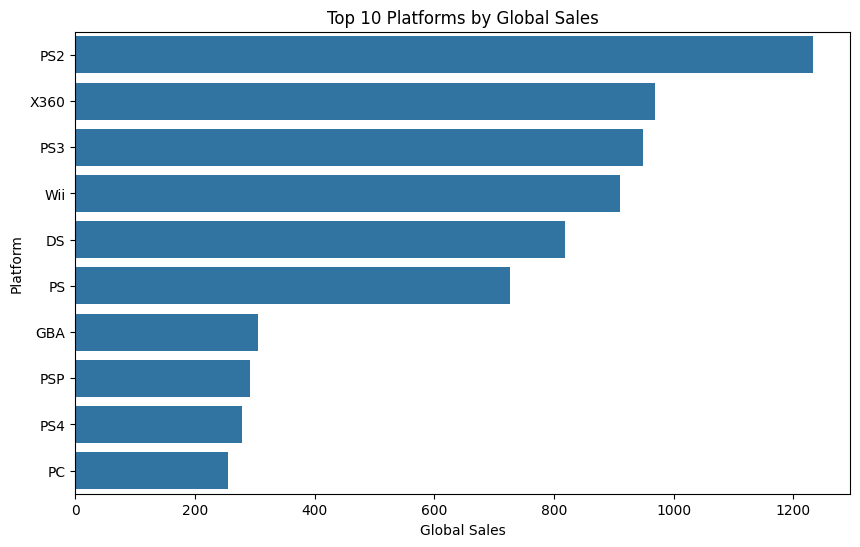

In [ ]:
top_platforms = platform_sales.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_platforms,
    x="total_sales",
    y="Platform"
)

plt.title("Top 10 Platforms by Global Sales")
plt.xlabel("Global Sales")
plt.ylabel("Platform")

plt.show()

Genre apa yang paling banyak menghasilkan global sales?

In [ ]:
query = """
SELECT
    Genre,
    SUM(Global_Sales) AS total_sales
FROM games
GROUP BY Genre
ORDER BY total_sales DESC
"""

genre_sales = pd.read_sql_query(query, conn)

genre_sales

,Genre,total_sales
0,Action,1722.84
1,Sports,1309.24
2,Shooter,1026.20
3,Role-Playing,923.83
4,Platform,829.13
5,Misc,789.87
6,Racing,726.76
7,Fighting,444.05
8,Simulation,389.69
9,Puzzle,242.21


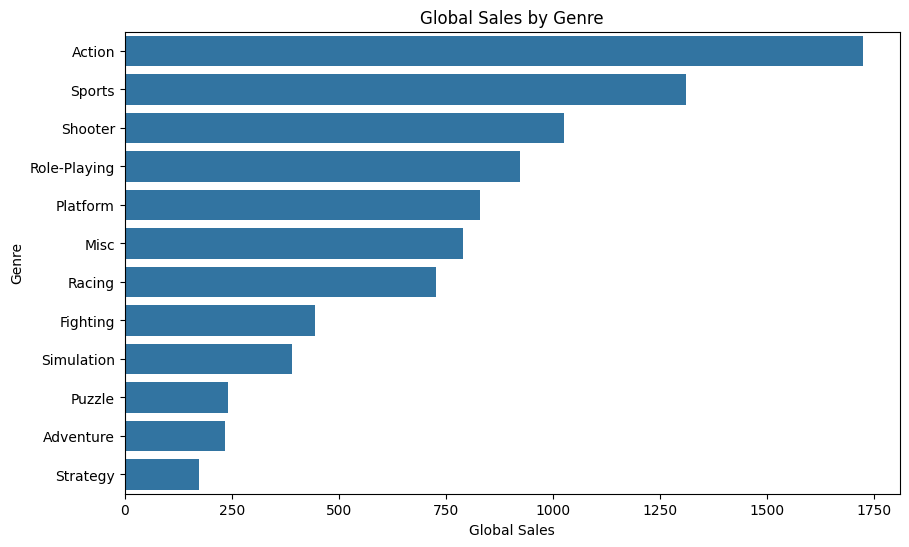

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=genre_sales,
    x="total_sales",
    y="Genre"
)

plt.title("Global Sales by Genre")
plt.xlabel("Global Sales")
plt.ylabel("Genre")

plt.show()

Publisher mana yang memiliki global sales tertinggi?

In [ ]:
query = """
SELECT
    Publisher,
    SUM(Global_Sales) AS total_sales
FROM games
WHERE Publisher IS NOT NULL
GROUP BY Publisher
ORDER BY total_sales DESC
LIMIT 10
"""

publisher_sales = pd.read_sql_query(query, conn)

publisher_sales

,Publisher,total_sales
0,Nintendo,1784.43
1,Electronic Arts,1093.39
2,Activision,721.41
3,Sony Computer Entertainment,607.28
4,Ubisoft,473.25
5,Take-Two Interactive,399.30
6,THQ,340.44
7,Konami Digital Entertainment,278.56
8,Sega,270.70
9,Namco Bandai Games,253.65


In [ ]:
query = """
SELECT
    SUM(NA_Sales) AS North_America,
    SUM(EU_Sales) AS Europe,
    SUM(JP_Sales) AS Japan,
    SUM(Other_Sales) AS Other_Regions
FROM games
"""

regional_sales = pd.read_sql_query(query, conn)

regional_sales

,North_America,Europe,Japan,Other_Regions
0,4327.38,2406.69,1284.27,788.89


In [ ]:
query = """
SELECT
    Year,
    SUM(Global_Sales) AS total_sales
FROM games
WHERE Year IS NOT NULL
GROUP BY Year
ORDER BY Year
"""

yearly_sales = pd.read_sql_query(query, conn)

yearly_sales.head()

,Year,total_sales
0,1980.0,11.38
1,1981.0,35.77
2,1982.0,28.86
3,1983.0,16.79
4,1984.0,50.36


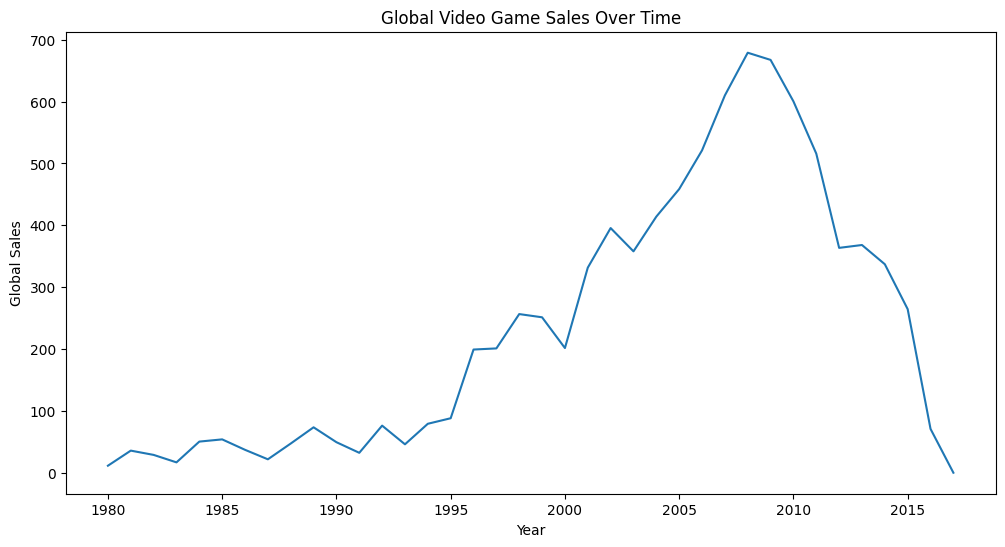

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly_sales,
    x="Year",
    y="total_sales"
)

plt.title("Global Video Game Sales Over Time")
plt.xlabel("Year")
plt.ylabel("Global Sales")

plt.show()

In [ ]:
query = """
SELECT
    Name,
    Global_Sales,
    CASE
        WHEN Global_Sales >= 5 THEN 'High'
        WHEN Global_Sales >= 1 THEN 'Medium'
        ELSE 'Low'
    END AS Sales_Category
FROM games
LIMIT 20
"""

sales_category = pd.read_sql_query(query, conn)

sales_category

,Name,Global_Sales,Sales_Category
0,Kaboom!,1.15,Medium
1,Boxing,0.77,Low
2,Ice Hockey,0.49,Low
3,Freeway,0.34,Low
4,Bridge,0.27,Low
5,Asteroids,4.31,Medium
6,Missile Command,2.76,Medium
7,Defender,1.05,Medium
8,Checkers,0.24,Low
9,Alien,0.79,Low


In [ ]:
query = """
SELECT
    CASE
        WHEN Global_Sales >= 5 THEN 'High'
        WHEN Global_Sales >= 1 THEN 'Medium'
        ELSE 'Low'
    END AS Sales_Category,
    COUNT(*) AS total_games
FROM games
GROUP BY Sales_Category
ORDER BY total_games DESC
"""

sales_category_count = pd.read_sql_query(
    query,
    conn
)

sales_category_count

,Sales_Category,total_games
0,Low,14232
1,Medium,1852
2,High,206


In [ ]:
df.shape

(16290, 10)

In [ ]:
platform_sales.head(10)

,Platform,total_sales
0,PS2,1233.46
1,X360,969.60
2,PS3,949.35
3,Wii,909.81
4,DS,818.62
5,PS,727.39
6,GBA,305.62
7,PSP,291.71
8,PS4,278.10
9,PC,254.70


In [ ]:
genre_sales

,Genre,total_sales
0,Action,1722.84
1,Sports,1309.24
2,Shooter,1026.20
3,Role-Playing,923.83
4,Platform,829.13
5,Misc,789.87
6,Racing,726.76
7,Fighting,444.05
8,Simulation,389.69
9,Puzzle,242.21


In [ ]:
publisher_sales

,Publisher,total_sales
0,Nintendo,1784.43
1,Electronic Arts,1093.39
2,Activision,721.41
3,Sony Computer Entertainment,607.28
4,Ubisoft,473.25
5,Take-Two Interactive,399.30
6,THQ,340.44
7,Konami Digital Entertainment,278.56
8,Sega,270.70
9,Namco Bandai Games,253.65


In [ ]:
regional_sales

,North_America,Europe,Japan,Other_Regions
0,4327.38,2406.69,1284.27,788.89


In [ ]:
yearly_sales

,Year,total_sales
0,1980.0,11.38
1,1981.0,35.77
2,1982.0,28.86
3,1983.0,16.79
4,1984.0,50.36
5,1985.0,53.94
6,1986.0,37.07
7,1987.0,21.74
8,1988.0,47.22
9,1989.0,73.45


Publisher mana yang menghasilkan lebih dari 300 juta global sales?

In [ ]:
query = """
SELECT
    Publisher,
    SUM(Global_Sales) AS total_sales
FROM games
WHERE Publisher IS NOT NULL
GROUP BY Publisher
HAVING SUM(Global_Sales) > 300
ORDER BY total_sales DESC
"""

publishers_over_300 = pd.read_sql_query(query, conn)

publishers_over_300

,Publisher,total_sales
0,Nintendo,1784.43
1,Electronic Arts,1093.39
2,Activision,721.41
3,Sony Computer Entertainment,607.28
4,Ubisoft,473.25
5,Take-Two Interactive,399.30
6,THQ,340.44


Game apa saja yang memiliki sales lebih tinggi daripada rata-rata seluruh game?

In [ ]:
query = """
SELECT
    Name,
    Platform,
    Genre,
    Global_Sales
FROM games
WHERE Global_Sales > (
    SELECT AVG(Global_Sales)
    FROM games
)
ORDER BY Global_Sales DESC
LIMIT 20
"""

above_average_games = pd.read_sql_query(query, conn)

above_average_games

,Name,Platform,Genre,Global_Sales
0,Wii Sports,Wii,Sports,82.74
1,Super Mario Bros.,NES,Platform,40.24
2,Mario Kart Wii,Wii,Racing,35.82
3,Wii Sports Resort,Wii,Sports,33.00
4,Pokemon Red/Pokemon Blue,GB,Role-Playing,31.37
5,Tetris,GB,Puzzle,30.26
6,New Super Mario Bros.,DS,Platform,30.01
7,Wii Play,Wii,Misc,29.02
8,New Super Mario Bros. Wii,Wii,Platform,28.62
9,Duck Hunt,NES,Shooter,28.31


In [ ]:
query = """
SELECT
    Genre,
    SUM(Global_Sales) AS total_sales
FROM games
GROUP BY Genre
ORDER BY total_sales DESC
"""

genre_ranking = pd.read_sql_query(query, conn)

genre_ranking["Rank"] = range(
    1,
    len(genre_ranking) + 1
)

genre_ranking

,Genre,total_sales,Rank
0,Action,1722.84,1
1,Sports,1309.24,2
2,Shooter,1026.20,3
3,Role-Playing,923.83,4
4,Platform,829.13,5
5,Misc,789.87,6
6,Racing,726.76,7
7,Fighting,444.05,8
8,Simulation,389.69,9
9,Puzzle,242.21,10


Genre apa yang paling kuat di North America?

In [ ]:
query = """
SELECT
    Genre,
    SUM(NA_Sales) AS north_america_sales
FROM games
GROUP BY Genre
ORDER BY north_america_sales DESC
"""

na_genre_sales = pd.read_sql_query(query, conn)

na_genre_sales

,Genre,north_america_sales
0,Action,861.77
1,Sports,670.09
2,Shooter,575.16
3,Platform,445.99
4,Misc,396.92
5,Racing,356.93
6,Role-Playing,326.50
7,Fighting,220.74
8,Simulation,181.51
9,Puzzle,122.01


Genre apa yang paling kuat di Jepang?

In [ ]:
query = """
SELECT
    Genre,
    SUM(JP_Sales) AS japan_sales
FROM games
GROUP BY Genre
ORDER BY japan_sales DESC
"""

jp_genre_sales = pd.read_sql_query(query, conn)

jp_genre_sales

,Genre,japan_sales
0,Role-Playing,350.29
1,Action,158.65
2,Sports,134.76
3,Platform,130.65
4,Misc,106.67
5,Fighting,87.15
6,Simulation,63.54
7,Puzzle,56.68
8,Racing,56.61
9,Adventure,51.99


In [ ]:
query = """
SELECT
    Platform,
    ROUND(SUM(Global_Sales), 2) AS total_sales
FROM games
GROUP BY Platform
ORDER BY total_sales DESC
LIMIT 5
"""

top_platforms = pd.read_sql_query(query, conn)

top_platforms

,Platform,total_sales
0,PS2,1233.46
1,X360,969.60
2,PS3,949.35
3,Wii,909.81
4,DS,818.62


## Key Findings

### 1. Platform Performance

PS2 generated the highest total global sales in the dataset, followed by X360, PS3, Wii, and DS.

### 2. Genre Performance

Action was the highest-performing genre in terms of global sales, followed by Sports and Shooter.

### 3. Publisher Performance

Nintendo generated the highest global sales among publishers, followed by Electronic Arts and Activision.

### 4. Regional Performance

North America recorded the highest total sales, followed by Europe, Japan, and Other Regions.

### 5. Sales Over Time

Global video game sales increased substantially during the 1990s and 2000s, reaching a high point around 2009 before declining in the following years.

## Conclusion

This project analyzed video game sales data using SQL and Python. SQL queries were used to aggregate sales, compare platforms and genres, rank publishers, analyze regional performance, and examine sales trends over time.

The results showed that PS2 was the highest-performing platform, Action was the leading genre, and Nintendo was the highest-selling publisher in the dataset. North America contributed the largest share of regional sales.

The project also introduced more advanced SQL concepts including GROUP BY, HAVING, CASE WHEN, and subqueries. These techniques allowed the analysis to move beyond simple data retrieval toward more meaningful business-oriented insights.